### Human in The loop

In [9]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [10]:
from langchain.chat_models import init_chat_model
from langchain_groq import ChatGroq
model = init_chat_model("groq:openai/gpt-oss-120b")
llm = ChatGroq(model="openai/gpt-oss-120b")

In [11]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

In [12]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list, add_messages]

In [13]:
graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """ Request assiistance from human """
    human_response = interrupt({"query": query})
    return human_response["data"]

tool = TavilySearch(max_results=2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State) -> State:
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

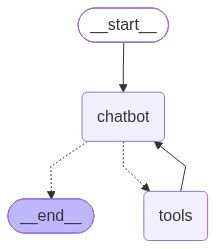

In [ ]:
graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools)
graph_builder.add_node("tools", tool_node)
graph_builder.add_conditional_edges(
    "chatbot", 
    # if the latest message (result) from assistant is a tool call -> tools_condition route to tools
    # else -> route to END
    tools_condition
    )
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
# graph_builder.add_edge("chatbot", END)

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)
graph

In [ ]:
config = {"configurable":{"thread_id":1}}

user_input = "I need some expert guidence for building an AI agent. Could you request assistance for me?"

events = graph.stream({"messages": user_input}, config=config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidence for building an AI chatbot. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_82f07fbe-9bcc-44a3-af69-c925342c1c42)
 Call ID: fc_82f07fbe-9bcc-44a3-af69-c925342c1c42
  Args:
    query: User requests expert guidance for building an AI chatbot. Please provide detailed assistance.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_82f07fbe-9bcc-44a3-af69-c925342c1c42)
 Call ID: fc_82f07fbe-9bcc-44a3-af69-c925342c1c42
  Args:
    query: User requests expert guidance for building an AI chatbot. Please provide detailed assistance.


In [ ]:
human_response = (
    "We, the experts are here to help! we'd recommand to check out Langgraph to build your agent."
"It's much more reliable and extensible than simple autonomous agents.")

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config=config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_82f07fbe-9bcc-44a3-af69-c925342c1c42)
 Call ID: fc_82f07fbe-9bcc-44a3-af69-c925342c1c42
  Args:
    query: User requests expert guidance for building an AI chatbot. Please provide detailed assistance.


NotImplementedError: Unsupported message type: <class 'langgraph.types.Command'>
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/MESSAGE_COERCION_FAILURE 